In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import optuna
import warnings
warnings.filterwarnings('ignore')

# Configurações globais de estilo
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.75)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.75)

# ==========================================
# UNIFORM FONT SIZES FOR ALL PLOTS
# ==========================================
#plt.rc('font', size=12)          # Default text sizes
#plt.rc('axes', titlesize=14)     # Axes title size
#plt.rc('axes', labelsize=12)     # X and Y labels size
#plt.rc('xtick', labelsize=11)    # X tick labels size
#plt.rc('ytick', labelsize=11)    # Y tick labels size
#plt.rc('legend', fontsize=11)    # Legend size
#plt.rc('figure', titlesize=16)   # Figure title size
plt.rcParams['font.family'] = 'serif'

PATH = os.getcwd()
sys.path.append(PATH)
PATH

'/Users/dylanperdigao/Github/CRAI-Code/src/1-ciarp2026'

In [ ]:
exp_A_tags = {
    '-FIXP-LB-LT': 'A2', '-FIXP-LB': 'A3', '-FIXP-LT': 'A4', '-FIXP': 'A1',
} 
exp_B_tags = {'-T1': 'T=1','-T5': 'T=5','-T10': 'T=10', '-T20': 'T=20', '-T30': 'T=30','-T40': 'T=40', '-T50': 'T=50'}
exp_C_tags = {'-GWTHR0.5': 'THR=0.5', '-GWTHR1.0': 'THR=1.0', '-GWTHR1.5': 'THR=1.5', '-GWTHR2.0': 'THR=2.0', '-GWTHR2.5': 'THR=2.5', '-GWTHR3.0': 'THR=3.0', '-GWTHR3.5': 'THR=3.5', '-GWTHR4.0': 'THR=4.0', '-GWTHR4.5': 'THR=4.5', '-GWTHR5.0': 'THR=5.0'}
data = []
databases = [
    "20260509-EXP_A.db",
    "20260509-EXP_B.db",
    "20260521-EXP_C.db",
]
def extract_data():
    for db in databases:
        db_path = os.path.join(PATH, "results", db)
        if not os.path.exists(db_path):
            print(f"Aviso: Ficheiro não encontrado - {db_path}")
            continue
        storage_url = f"sqlite:///{db_path}"
        print(f"Extraindo dados de: {db}")
        try:
            summaries = optuna.get_all_study_summaries(storage=storage_url)
            for summary in summaries:
                study_name = summary.study_name
                study = optuna.load_study(study_name=study_name, storage=storage_url)
                model = "CSNN" if "CSNN" in study_name else "FFSNN" if "FFSNN" in study_name else "Other"
                exp_group = "Unknown"
                has_gwt = "GWT" in study_name
                timesteps = int(study_name.split('-')[4][1:])
                if "EXP_A" in db or "A-" in study_name:
                    exp_group = "Exp A (Learning)"
                    dataset='BAF-Base'
                    config = '-'.join(study_name.split('-')[5:-1]) if len(study_name.split('-')) > 6 else "FIX"
                    gwt_threshold = "1.5-3.0"
                elif  "EXP_B" in db or "B-" in study_name:
                    exp_group = "Exp B (Timesteps)"
                    dataset='BAF-Base'
                    config = 'FIX'
                    gwt_threshold = "1.5-3.0"
                elif  "EXP_C" in db or "C-" in study_name:
                    exp_group = "Exp C (GWT Threshold)"
                    dataset='BAF-Base'
                    config = 'FIX'
                    gwt_threshold = float(study_name.split('-GWTHR')[-1]) if has_gwt else "N/A"
                for trial in study.trials[:100]:
                    if trial.state == optuna.trial.TrialState.COMPLETE:
                        row = {
                            'Exp_Group': exp_group,
                            'Model': model,
                            'Config': config,
                            'GWT': has_gwt,
                            'Timesteps': timesteps,
                            'GW-Threshold': gwt_threshold,
                            'Dataset': dataset,
                            'Accuracy': trial.user_attrs.get('@perf accuracy', np.nan),
                            'Precision': trial.user_attrs.get('@perf precision', np.nan),
                            'Recall': trial.user_attrs.get('@perf recall', np.nan),
                            'F1-Score': trial.user_attrs.get('@perf f1_score', np.nan),
                            'PE$_{\\text{Age}}$': trial.user_attrs.get('@fair fpr_ratio_age', np.nan),
                            'PE$_{\\text{income}}$': trial.user_attrs.get('@fair fpr_ratio_income', np.nan),
                            'PE$_{\\text{Employment}}$': trial.user_attrs.get('@fair fpr_ratio_employment', np.nan),
                            'ROC-AUC': trial.user_attrs.get('@perf roc_auc', np.nan),
                            'PR-AUC': trial.user_attrs.get('@perf pr_auc', np.nan)
                        }
                        data.append(row)
        except Exception as e:
            print(f"Erro a ler {db}: {e}")         
extract_data()
df = pd.DataFrame(data)
display(df.columns.tolist())
display(df.describe())
display(df.head())

Extraindo dados de: 20260509-EXP_A.db
Extraindo dados de: 20260509-EXP_B.db
Extraindo dados de: 20260521-EXP_C.db


['Exp_Group',
 'Model',
 'Config',
 'GWT',
 'Timesteps',
 'GW-Threshold',
 'Dataset',
 'Accuracy',
 'Precision',
 'Recall',
 'F1-Score',
 'PE$_{\\text{Age}}$',
 'PE$_{\\text{income}}$',
 'PE$_{\\text{Employment}}$',
 'ROC-AUC',
 'PR-AUC']

,Timesteps,Accuracy,Precision,Recall,F1-Score,PE$_{\text{Age}}$,PE$_{\text{income}}$,PE$_{\text{Employment}}$,ROC-AUC,PR-AUC
count,5935.000000,5935.000000,5935.000000,5935.000000,5935.000000,5935.000000,5935.000000,5935.000000,5935.000000,5935.000000
mean,22.367313,0.947774,0.135997,0.471536,0.210590,0.321643,0.293085,0.615381,0.859354,0.173864
std,10.317583,0.004384,0.009486,0.036912,0.010609,0.045536,0.058811,0.088036,0.016104,0.022807
min,5.000000,0.942133,0.097018,0.281513,0.151130,0.180866,0.108404,0.286650,0.683608,0.063450
25%,20.000000,0.944704,0.130147,0.452381,0.203691,0.291518,0.251720,0.555312,0.854337,0.163146
50%,20.000000,0.946480,0.135056,0.477591,0.210876,0.318177,0.289713,0.609097,0.863190,0.176207
75%,20.000000,0.949341,0.139968,0.498599,0.217410,0.348465,0.330433,0.667937,0.869256,0.186690
max,50.000000,0.971996,0.220139,0.540616,0.271359,0.637674,0.578198,0.998386,0.881071,0.310435


,Exp_Group,Model,Config,GWT,Timesteps,GW-Threshold,Dataset,Accuracy,Precision,Recall,F1-Score,PE$_{\text{Age}}$,PE$_{\text{income}}$,PE$_{\text{Employment}}$,ROC-AUC,PR-AUC
0,Exp A (Learning),FFSNN,FIX,True,20,1.5-3.0,BAF-Base,0.955805,0.140444,0.390056,0.206526,0.271823,0.390204,0.683766,0.828958,0.126580
1,Exp A (Learning),FFSNN,FIX,True,20,1.5-3.0,BAF-Base,0.946295,0.125174,0.441176,0.195016,0.299335,0.272877,0.721045,0.851598,0.157672
2,Exp A (Learning),FFSNN,FIX,True,20,1.5-3.0,BAF-Base,0.946862,0.124596,0.432073,0.193417,0.319779,0.202564,0.640876,0.854100,0.196868
3,Exp A (Learning),FFSNN,FIX,True,20,1.5-3.0,BAF-Base,0.945314,0.131479,0.483193,0.206711,0.310955,0.209066,0.573196,0.860623,0.180688
4,Exp A (Learning),FFSNN,FIX,True,20,1.5-3.0,BAF-Base,0.947905,0.134129,0.464286,0.208131,0.297582,0.280171,0.578828,0.856908,0.167205


In [3]:
print(df['Exp_Group'].unique())
print(df['Model'].unique())
print(df['Config'].unique())
print(df['GWT'].unique())
print(df['Timesteps'].unique())
print(df['Dataset'].unique())

['Exp A (Learning)' 'Exp B (Timesteps)' 'Exp C (GWT Threshold)']
['FFSNN' 'CSNN']
['FIX' 'LT' 'LT-LB' 'LB']
[ True False]
[20  5 10 30 40 50]
['BAF-Base']


In [ ]:
print(df[df['Exp_Group'] == 'Exp C (GWT Threshold)']['GW-Threshold'].unique())
df['GW-Threshold'] = pd.to_numeric(df['GW-Threshold'], errors='coerce')
def get_arch_name(row):
    return row['Model'] + (" + GWT" if row['GWT'] else "")
df['Architecture'] = df.apply(get_arch_name, axis=1)
config_map = {'FIX': 'Fixed', 'LB': 'Learn Decays', 'LT': 'Learn Thresholds', 'LT-LB': 'Learn Both'}
arch_map = {'CSNN + GWT': 'CSNN + GW', 'CSNN': 'CSNN', 'FFSNN + GWT': 'FFSNN + GW', 'FFSNN': 'FFSNN'}
arch_order = ['CSNN + GW', 'CSNN', 'FFSNN + GW', 'FFSNN']
config_order = ['Fixed', 'Learn Decays', 'Learn Thresholds', 'Learn Both']
df['Config'] = df['Config'].replace(config_map)
df['Architecture'] = df['Architecture'].replace(arch_map)

['N/A' 0.5 1.0 1.5 2.0 2.5 3.0 3.5 4.0 4.5 5.0]


In [ ]:
tab20 = plt.get_cmap('tab20').colors
model_colors = {
    'CSNN + GW': (tab20[0], 'o'),         
    'CSNN': (tab20[1], 's'),    
    'FFSNN + GW': (tab20[2], '^'),
    'FFSNN': (tab20[3], 'D')
} 
model_palette = {arch: color for arch, (color, marker) in model_colors.items()}
model_markers = {arch: marker for arch, (color, marker) in model_colors.items()}
learning_colors = {
    'Fixed': (tab20[-2], 'o'),         
    'Learn Decays': (tab20[-4], 's'),    
    'Learn Thresholds': (tab20[-6], '^'),
    'Learn Both': (tab20[-10], 'D')
} 
learning_palette = {cfg: color for cfg, (color, marker) in learning_colors.items()}
learning_markers = {cfg: marker for cfg, (color, marker) in learning_colors.items()}
viridis = plt.get_cmap('viridis_r')
truncated_colors = viridis(np.linspace(0.3, 1.0, 256))
blue_green_cmap = mcolors.LinearSegmentedColormap.from_list('viridis_truncated', truncated_colors)
colormap = blue_green_cmap

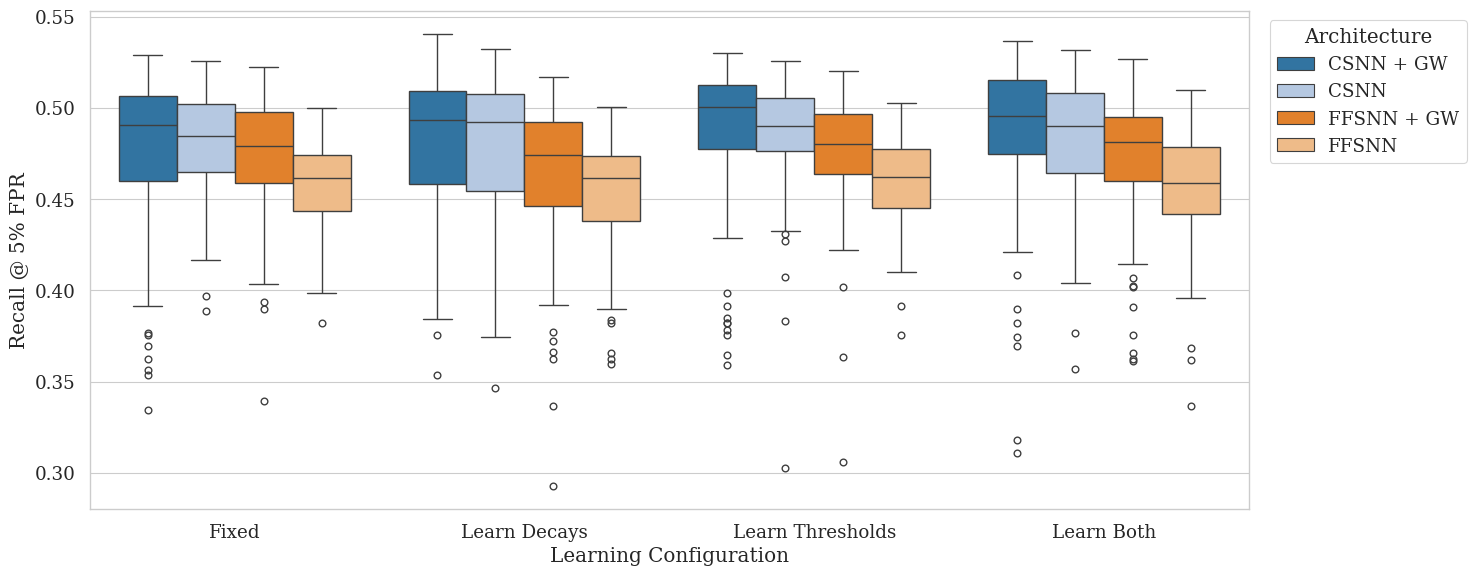

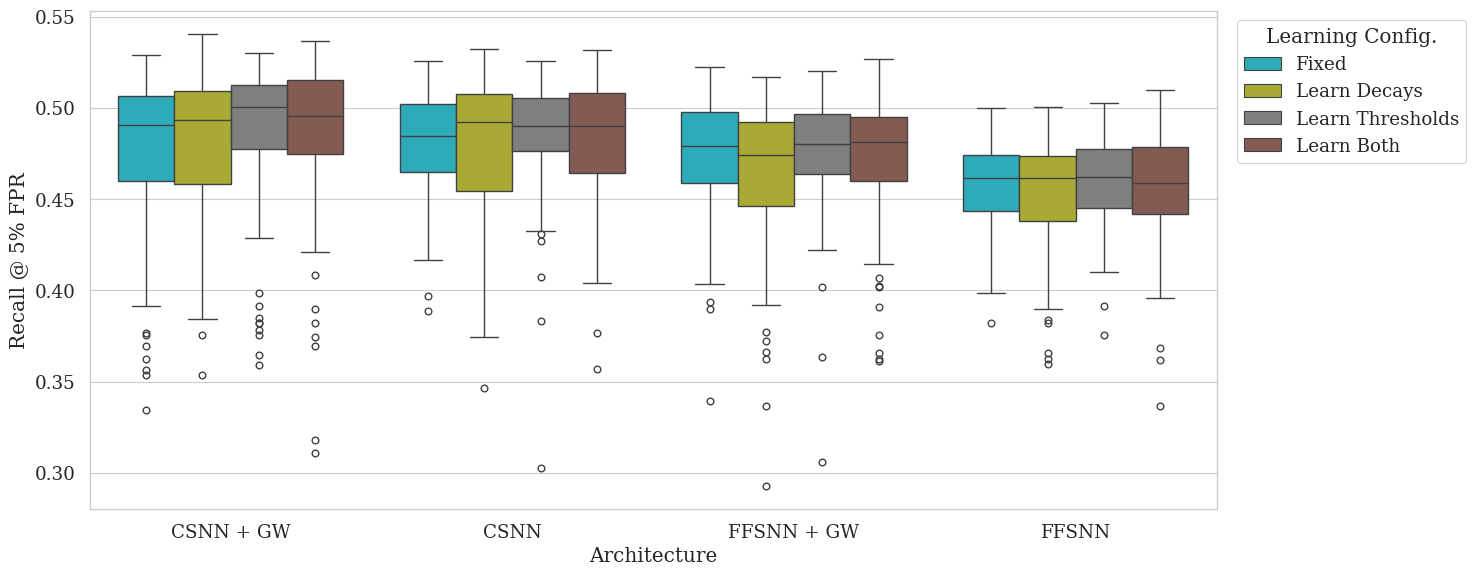

In [ ]:
fig1a, ax1a = plt.subplots(figsize=(15, 6))
df_expA = df[df['Exp_Group'] == 'Exp A (Learning)'].copy().sort_values(by=['Config', 'Architecture'], key=lambda x: x.map({**{k: i for i, k in enumerate(config_order)}, **{k: i for i, k in enumerate(arch_order)}}))
sns.boxplot(data=df_expA, x='Config', y='Recall', hue='Architecture', palette=model_palette, ax=ax1a)
ax1a.set_ylabel("Recall @ 5% FPR")
ax1a.set_xlabel("Learning Configuration")
plt.legend(title="Architecture", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig("plots/fig1a_ablation.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig1b, ax1b = plt.subplots(figsize=(15, 6))
df_expA = df[df['Exp_Group'] == 'Exp A (Learning)'].copy().sort_values(by=['Architecture', 'Config'], key=lambda x: x.map({**{k: i for i, k in enumerate(arch_order)}, **{k: i for i, k in enumerate(config_order)}}))
sns.boxplot(data=df_expA, x='Architecture', y='Recall', hue='Config', palette=learning_palette, ax=ax1b)
ax1b.set_ylabel("Recall @ 5% FPR")
ax1b.set_xlabel("Architecture")
plt.legend(title="Learning Config.", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig("plots/fig1b_ablation.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
df_expA

,Exp_Group,Model,Config,GWT,Timesteps,GW-Threshold,Dataset,Accuracy,Precision,Recall,F1-Score,PE$_{\text{Age}}$,PE$_{\text{income}}$,PE$_{\text{Employment}}$,ROC-AUC,PR-AUC,Architecture
293,Exp A (Learning),CSNN,Fixed,True,20,NaN,BAF-Base,0.944415,0.136823,0.521709,0.216790,0.354335,0.317575,0.543317,0.874042,0.192886,CSNN + GW
294,Exp A (Learning),CSNN,Fixed,True,20,NaN,BAF-Base,0.954958,0.155957,0.465686,0.233661,0.275086,0.421198,0.634198,0.874730,0.189362,CSNN + GW
295,Exp A (Learning),CSNN,Fixed,True,20,NaN,BAF-Base,0.947730,0.141334,0.501401,0.220511,0.392922,0.361599,0.571144,0.876203,0.187856,CSNN + GW
296,Exp A (Learning),CSNN,Fixed,True,20,NaN,BAF-Base,0.952996,0.142071,0.434174,0.214088,0.401950,0.297818,0.628026,0.846034,0.159145,CSNN + GW
297,Exp A (Learning),CSNN,Fixed,True,20,NaN,BAF-Base,0.946625,0.140358,0.511204,0.220244,0.248929,0.320383,0.678086,0.870279,0.196096,CSNN + GW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866,Exp A (Learning),FFSNN,Learn Both,False,20,NaN,BAF-Base,0.944467,0.132626,0.499300,0.209583,0.299550,0.301544,0.544403,0.866340,0.183397,FFSNN
867,Exp A (Learning),FFSNN,Learn Both,False,20,NaN,BAF-Base,0.944167,0.130685,0.492997,0.206603,0.273797,0.265889,0.639534,0.856299,0.191712,FFSNN
868,Exp A (Learning),FFSNN,Learn Both,False,20,NaN,BAF-Base,0.944725,0.135291,0.509804,0.213835,0.328627,0.335564,0.531082,0.865658,0.193239,FFSNN
869,Exp A (Learning),FFSNN,Learn Both,False,20,NaN,BAF-Base,0.947265,0.129357,0.449580,0.200908,0.333754,0.249799,0.540503,0.858018,0.173459,FFSNN


In [8]:
median_values = df_expA.groupby(['Architecture', 'Config'])['Recall'].median().reset_index()
max_values = df_expA.groupby(['Architecture', 'Config'])['Recall'].max().reset_index()
display(median_values)
display(max_values)

,Architecture,Config,Recall
0,CSNN,Fixed,0.484594
1,CSNN,Learn Both,0.490196
2,CSNN,Learn Decays,0.492297
3,CSNN,Learn Thresholds,0.490196
4,CSNN + GW,Fixed,0.490896
5,CSNN + GW,Learn Both,0.495798
6,CSNN + GW,Learn Decays,0.493347
7,CSNN + GW,Learn Thresholds,0.500700
8,FFSNN,Fixed,0.461485
9,FFSNN,Learn Both,0.459034


,Architecture,Config,Recall
0,CSNN,Fixed,0.525910
1,CSNN,Learn Both,0.531513
2,CSNN,Learn Decays,0.532213
3,CSNN,Learn Thresholds,0.525910
4,CSNN + GW,Fixed,0.528711
5,CSNN + GW,Learn Both,0.536415
6,CSNN + GW,Learn Decays,0.540616
7,CSNN + GW,Learn Thresholds,0.530112
8,FFSNN,Fixed,0.500000
9,FFSNN,Learn Both,0.509804


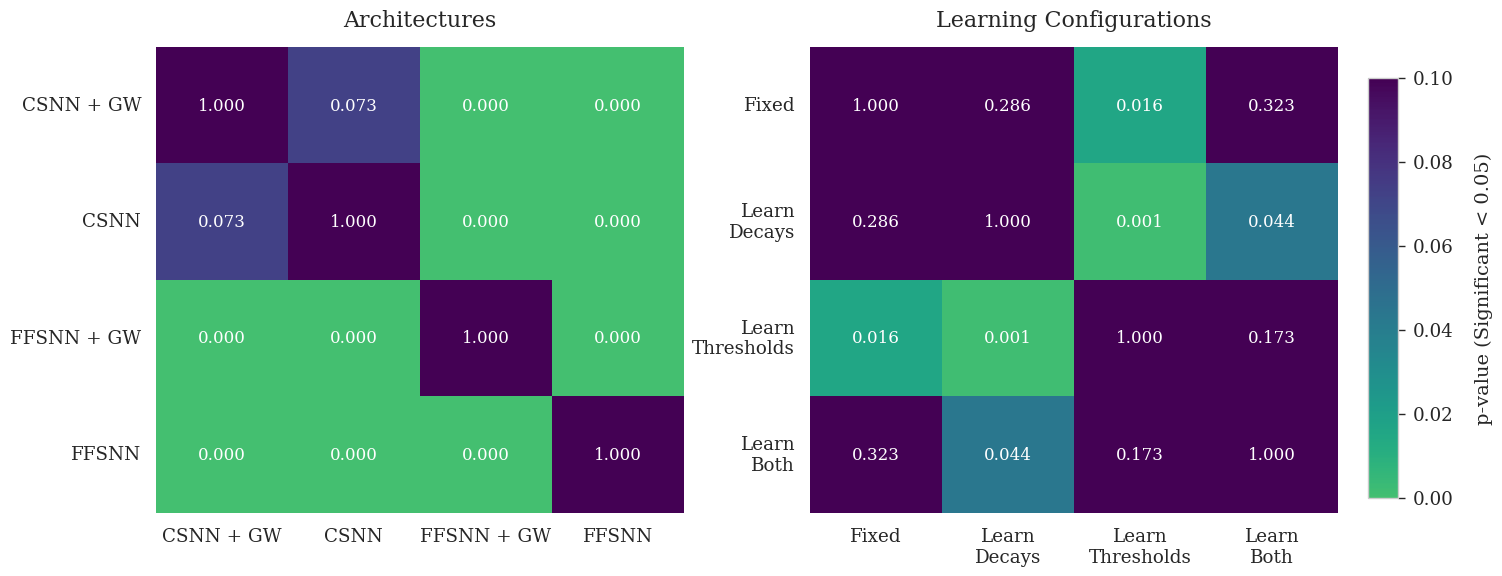

In [ ]:
df_A = df[df['Exp_Group'] == 'Exp A (Learning)'].copy()

p_matrix_arch = np.zeros((4, 4))
for i, a1 in enumerate(arch_order):
    v1 = df_A[df_A['Architecture'] == a1]['Recall'].dropna()
    for j, a2 in enumerate(arch_order):
        v2 = df_A[df_A['Architecture'] == a2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            if i == j:
                p_matrix_arch[i, j] = 1.0
            else:
                _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
                p_matrix_arch[i, j] = p_val
        else:
            p_matrix_arch[i, j] = 1.0

p_matrix_config = np.zeros((4, 4))
for i, c1 in enumerate(config_order):
    v1 = df_A[df_A['Config'] == c1]['Recall'].dropna()
    for j, c2 in enumerate(config_order):
        v2 = df_A[df_A['Config'] == c2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            if i == j:
                p_matrix_config[i, j] = 1.0
            else:
                _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
                p_matrix_config[i, j] = p_val
        else:
            p_matrix_config[i, j] = 1.0

fig, axes = plt.subplots(1,2,figsize=(15, 6))
# =========================================================
# Plot Matrix 1
# =========================================================
h1 = sns.heatmap(p_matrix_arch, xticklabels=arch_order, yticklabels=arch_order, annot=True, 
            cmap=colormap, vmin=0, vmax=0.1, ax=axes[0], fmt=".3f", 
            annot_kws={'size': 12}, cbar=False)
axes[0].set_title('Architectures', pad=15, fontsize=16)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# =========================================================
# Plot Matrix 2
# =========================================================
config_order = ['Fixed', 'Learn\nDecays', 'Learn\nThresholds', 'Learn\nBoth']
h2 = sns.heatmap(p_matrix_config, xticklabels=config_order, yticklabels=config_order, annot=True, 
            cmap=colormap, vmin=0, vmax=0.1, ax=axes[1], fmt=".3f", 
            annot_kws={'size': 12}, cbar=False)
axes[1].set_title('Learning Configurations', pad=15, fontsize=16)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

# =========================================================
# SHARED COLORBAR
# =========================================================
plt.tight_layout() 
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(axes[0].collections[0], cax=cbar_ax)
cbar.set_label(f'p-value (Significant < 0.05)', size=14, labelpad=15)

plt.savefig("plots/fig1c_ablation.pdf", dpi=300, bbox_inches='tight')
plt.show()

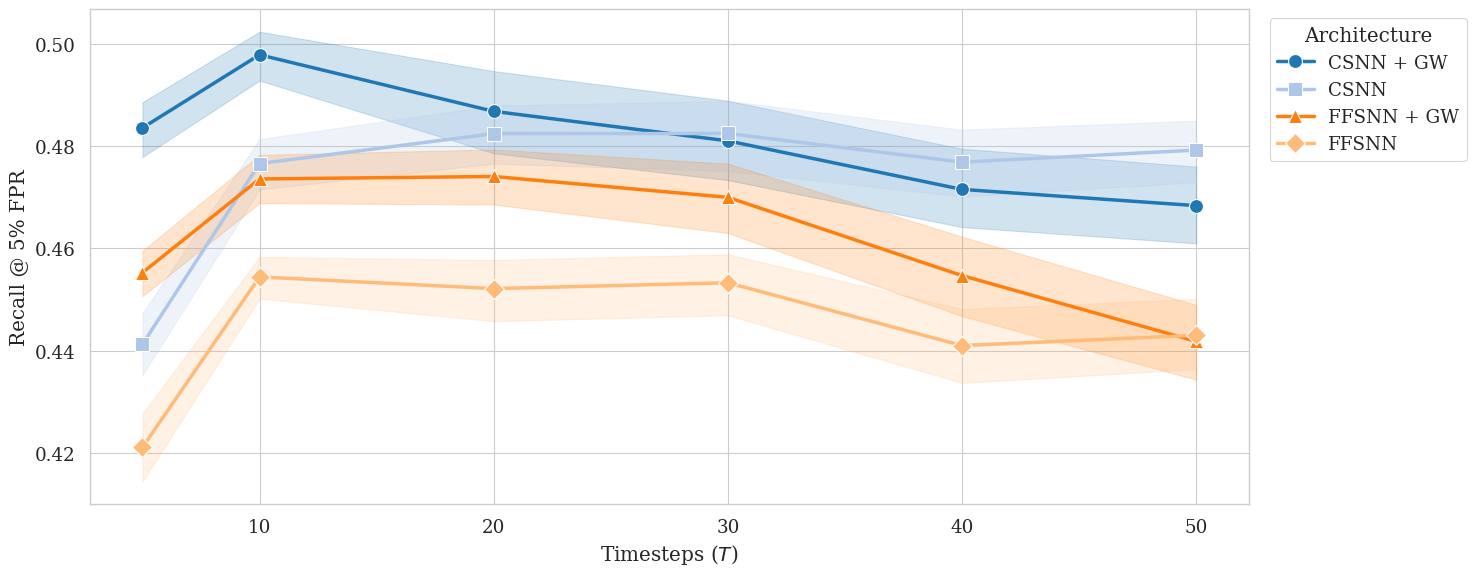

In [ ]:
fig2, ax2 = plt.subplots(figsize=(15, 6))
df_expB = df[df['Exp_Group'] == 'Exp B (Timesteps)'].copy().sort_values(by=['Architecture', 'Timesteps'], key=lambda x: x.map({**{k: i for i, k in enumerate(arch_order)}, **{k: i for i, k in enumerate(sorted(df['Timesteps'].unique()))}}))
sns.lineplot(data=df_expB, x='Timesteps', y='Recall', hue='Architecture', style='Architecture', markers=model_markers, dashes=False, palette=model_palette, err_style="band", linewidth=2.5, markersize=10, ax=ax2)
#ax2.set_title("Temporal Dynamics: Impact of Integration Time")
ax2.set_ylabel("Recall @ 5% FPR")
ax2.set_xlabel("Timesteps ($T$)")
plt.legend(title="Architecture", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig("plots/fig2a_temporal.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
max_values = df_expB.groupby(['Architecture', 'Timesteps'])['Recall'].max().reset_index()
mean_values = df_expB.groupby(['Architecture', 'Timesteps'])['Recall'].mean().reset_index()
display(max_values)
display(mean_values)

,Architecture,Timesteps,Recall
0,CSNN,5,0.498599
1,CSNN,10,0.525910
2,CSNN,20,0.526611
3,CSNN,30,0.528711
4,CSNN,40,0.525910
5,CSNN,50,0.536415
6,CSNN + GW,5,0.524510
7,CSNN + GW,10,0.533613
8,CSNN + GW,20,0.540616
9,CSNN + GW,30,0.532913


,Architecture,Timesteps,Recall
0,CSNN,5,0.441270
1,CSNN,10,0.476599
2,CSNN,20,0.482439
3,CSNN,30,0.482471
4,CSNN,40,0.476869
5,CSNN,50,0.479223
6,CSNN + GW,5,0.483565
7,CSNN + GW,10,0.497855
8,CSNN + GW,20,0.486801
9,CSNN + GW,30,0.481029


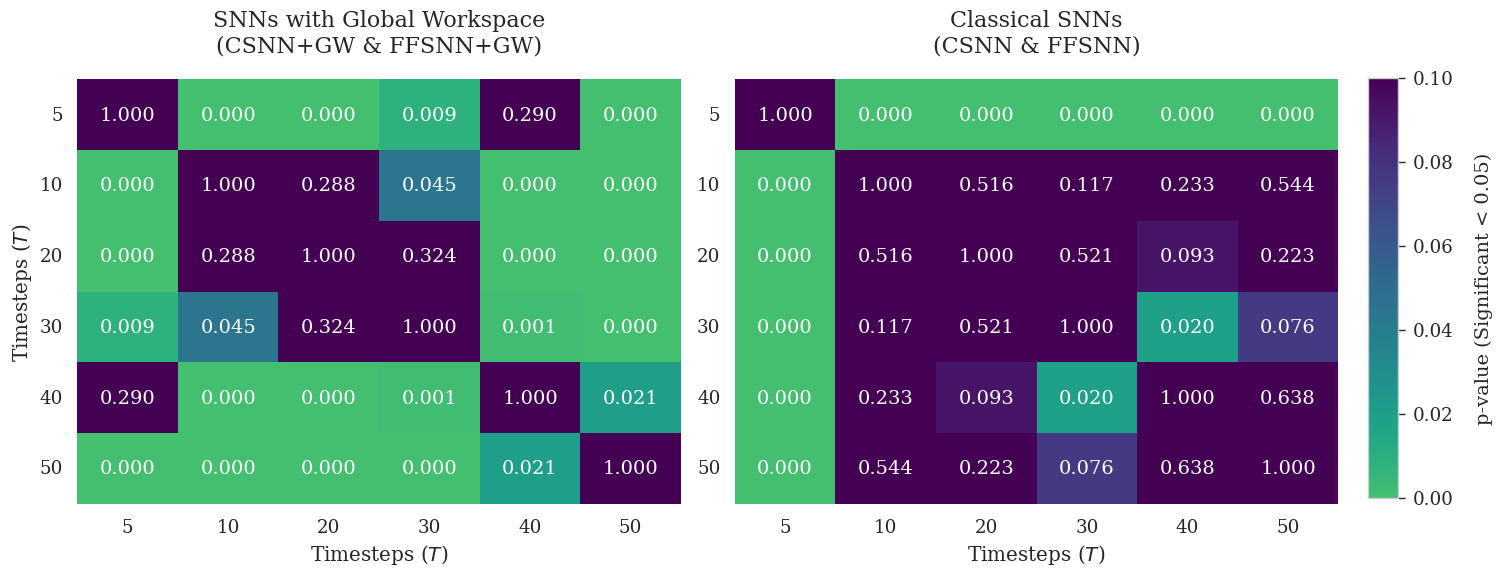

In [ ]:

df_B = df[df['Exp_Group'] == 'Exp B (Timesteps)'].copy().sort_values(by=['Architecture', 'Timesteps'], key=lambda x: x.map({**{k: i for i, k in enumerate(arch_order)}, **{k: i for i, k in enumerate(sorted(df['Timesteps'].unique()))}}))
timesteps = sorted(df_B['Timesteps'].unique())
df_gwt = df_B[df_B['Architecture'].str.contains('GW')]
df_classic = df_B[~df_B['Architecture'].str.contains('GW')]
p_matrix_gwt = np.zeros((len(timesteps), len(timesteps)))
p_matrix_classic = np.zeros((len(timesteps), len(timesteps)))

for i, t1 in enumerate(timesteps):
    v1 = df_gwt[df_gwt['Timesteps'] == t1]['Recall'].dropna()
    for j, t2 in enumerate(timesteps):
        v2 = df_gwt[df_gwt['Timesteps'] == t2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            if i == j:
                p_matrix_gwt[i, j] = 1.0 # Self comparison
            else:
                _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
                p_matrix_gwt[i, j] = p_val
        else:
            p_matrix_gwt[i, j] = 1.0

for i, t1 in enumerate(timesteps):
    v1 = df_classic[df_classic['Timesteps'] == t1]['Recall'].dropna()
    for j, t2 in enumerate(timesteps):
        v2 = df_classic[df_classic['Timesteps'] == t2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            if i == j:
                p_matrix_classic[i, j] = 1.0 # Self comparison
            else:
                _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
                p_matrix_classic[i, j] = p_val
        else:
            p_matrix_classic[i, j] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# =========================================================
# Plot Matrix 1
# =========================================================
h1 = sns.heatmap(p_matrix_gwt, xticklabels=timesteps, yticklabels=timesteps, annot=True, 
                 cmap=colormap, vmin=0, vmax=0.1, ax=axes[0], fmt=".3f", 
                 annot_kws={'size': 14}, cbar=False) 
axes[0].set_title('SNNs with Global Workspace\n(CSNN+GW & FFSNN+GW)', pad=20, fontsize=16)
axes[0].set_ylabel("Timesteps ($T$)")
axes[0].set_xlabel("Timesteps ($T$)")
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# =========================================================
# Plot Matrix 2
# =========================================================
h2 = sns.heatmap(p_matrix_classic, xticklabels=timesteps, yticklabels=timesteps, annot=True, 
                 cmap=colormap, vmin=0, vmax=0.1, ax=axes[1], fmt=".3f", 
                 annot_kws={'size': 14}, cbar=False)
axes[1].set_title('Classical SNNs\n(CSNN & FFSNN)', pad=20, fontsize=16)
axes[1].set_xlabel("Timesteps ($T$)")
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

# =========================================================
# SHARED COLORBAR
# =========================================================
plt.tight_layout() 
fig.subplots_adjust(right=0.9) 
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
cbar = fig.colorbar(axes[0].collections[0], cax=cbar_ax)
cbar.set_label('p-value (Significant < 0.05)', size=14, labelpad=15)

plt.savefig("plots/fig2b_temporal.pdf", dpi=300, bbox_inches='tight')
plt.show()

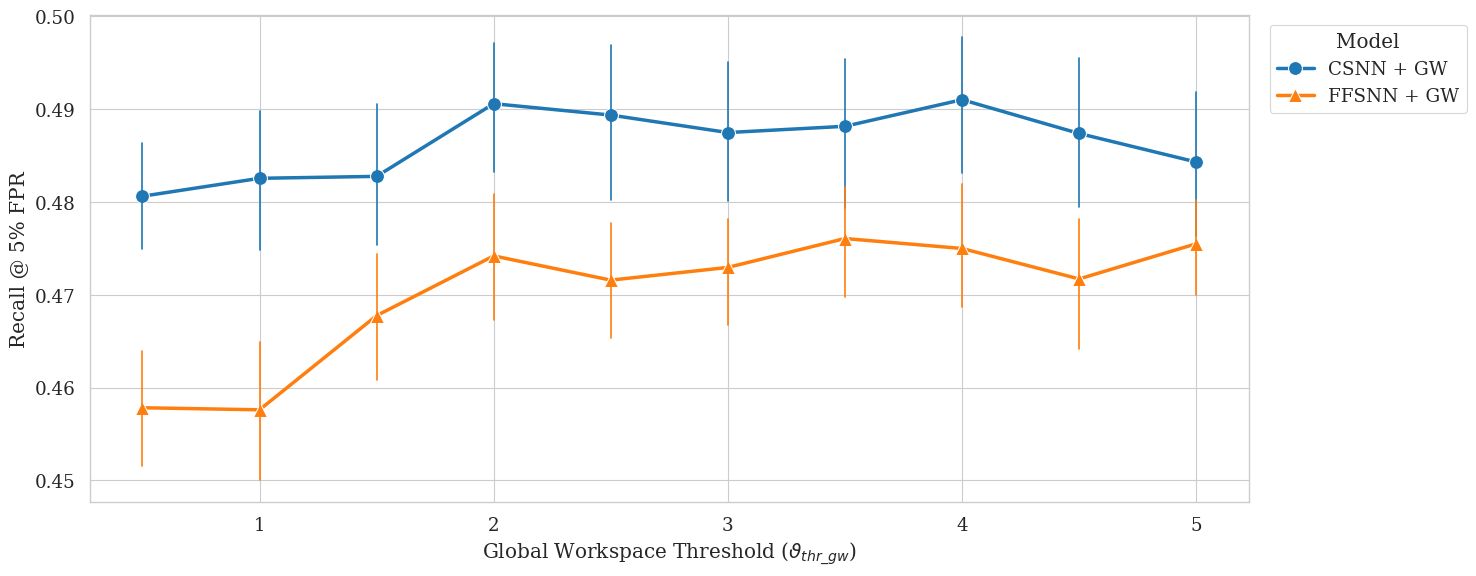

In [ ]:
fig3, ax3 = plt.subplots(figsize=(15, 6))
df_expC = df[(df['Exp_Group'] == 'Exp C (GWT Threshold)') & (df['GWT'] == True)].copy().sort_values(by=['Architecture', 'GW-Threshold'], key=lambda x: x.map({**{k: i for i, k in enumerate(arch_order)}, **{k: i for i, k in enumerate(sorted(df['GW-Threshold'].dropna().unique()))}}))
df_expC = df_expC.dropna(subset=['GW-Threshold'])
sns.lineplot(data=df_expC, x='GW-Threshold', y='Recall', hue='Architecture', style='Architecture', markers=model_markers, dashes=False, 
             linewidth=2.5, markersize=10, palette=model_palette, err_style="bars", err_kws={'capsize':5}, ax=ax3)
ax3.set_ylabel("Recall @ 5% FPR")
ax3.set_xlabel("Global Workspace Threshold ($\\vartheta_{thr\_gw}$)")
plt.legend(title="Model", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig("plots/fig3a_gw_threshold.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
max_values = df_expC.groupby(['Architecture', 'GW-Threshold'])['Recall'].max().reset_index()
display(max_values)

,Architecture,GW-Threshold,Recall
0,CSNN + GW,0.5,0.528711
1,CSNN + GW,1.0,0.537815
2,CSNN + GW,1.5,0.535014
3,CSNN + GW,2.0,0.535714
4,CSNN + GW,2.5,0.534314
5,CSNN + GW,3.0,0.530112
6,CSNN + GW,3.5,0.533613
7,CSNN + GW,4.0,0.539216
8,CSNN + GW,4.5,0.534314
9,CSNN + GW,5.0,0.535714


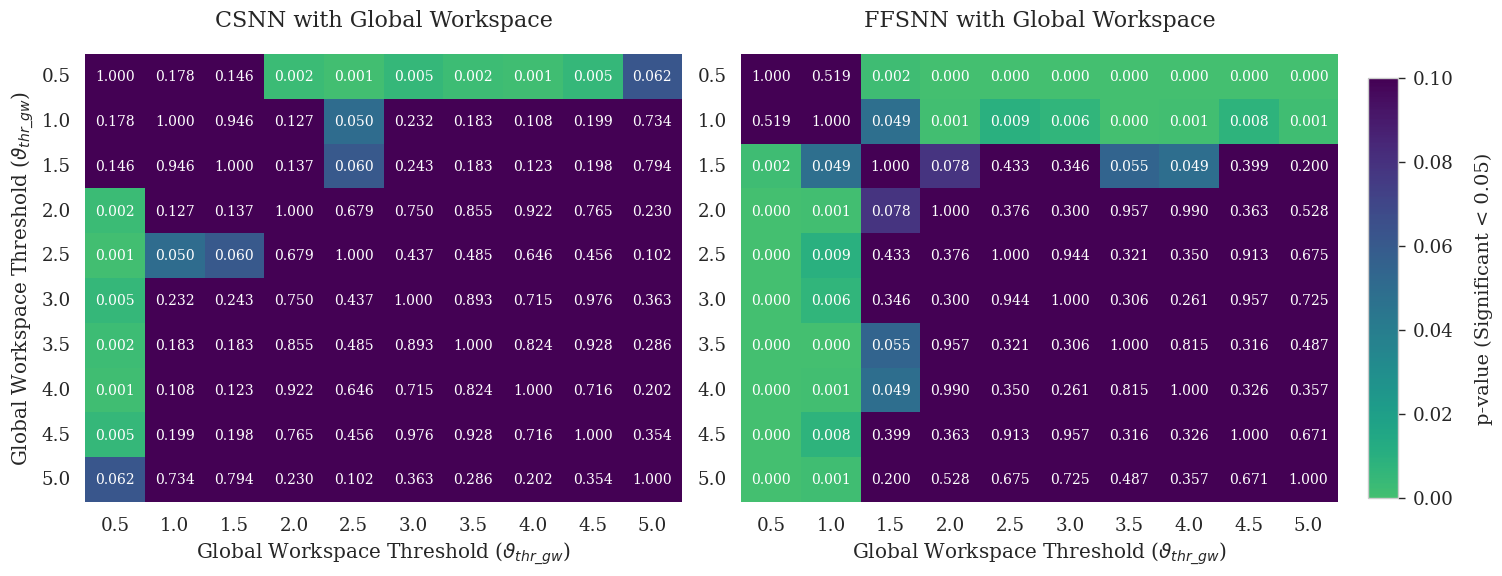

In [ ]:

df_C = df[(df['Exp_Group'] == 'Exp C (GWT Threshold)') & (df['GWT'] == True)].copy()
df_C['GW-Threshold'] = pd.to_numeric(df_C['GW-Threshold'], errors='coerce')
df_C = df_C.dropna(subset=['GW-Threshold'])
thresholds = sorted(df_C['GW-Threshold'].unique())
p_matrix_csnn = np.zeros((len(thresholds), len(thresholds)))
p_matrix_ffsnn = np.zeros((len(thresholds), len(thresholds)))

df_csnn = df_C[df_C['Architecture'] == 'CSNN + GW']
for i, t1 in enumerate(thresholds):
    v1 = df_csnn[df_csnn['GW-Threshold'] == t1]['Recall'].dropna()
    for j, t2 in enumerate(thresholds):
        v2 = df_csnn[df_csnn['GW-Threshold'] == t2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            if i == j:
                p_matrix_csnn[i, j] = 1.0
            else:
                _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
                p_matrix_csnn[i, j] = p_val
        else:
             p_matrix_csnn[i, j] = 1.0

df_ffsnn = df_C[df_C['Architecture'] == 'FFSNN + GW']
for i, t1 in enumerate(thresholds):
    v1 = df_ffsnn[df_ffsnn['GW-Threshold'] == t1]['Recall'].dropna()
    for j, t2 in enumerate(thresholds):
        v2 = df_ffsnn[df_ffsnn['GW-Threshold'] == t2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            if i == j:
                p_matrix_ffsnn[i, j] = 1.0
            else:
                _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
                p_matrix_ffsnn[i, j] = p_val
        else:
             p_matrix_ffsnn[i, j] = 1.0


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# =========================================================
# Plot Matrix 1
# =========================================================
h1 = sns.heatmap(p_matrix_csnn, xticklabels=thresholds, yticklabels=thresholds, annot=True, 
                 cmap=colormap, vmin=0, vmax=0.1, ax=axes[0], fmt=".3f", 
                 annot_kws={'size': 10}, cbar=False)
axes[0].set_title('CSNN with Global Workspace', pad=20, fontsize=16)
axes[0].set_ylabel('Global Workspace Threshold ($\\vartheta_{thr\_gw}$)')
axes[0].set_xlabel('Global Workspace Threshold ($\\vartheta_{thr\_gw}$)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# =========================================================
# Plot Matrix 2
# =========================================================
h2 = sns.heatmap(p_matrix_ffsnn, xticklabels=thresholds, yticklabels=thresholds, annot=True, 
                 cmap=colormap, vmin=0, vmax=0.1, ax=axes[1], fmt=".3f", 
                 annot_kws={'size': 10}, cbar=False)
axes[1].set_title('FFSNN with Global Workspace', pad=20, fontsize=16)
axes[1].set_xlabel('Global Workspace Threshold ($\\vartheta_{thr\_gw}$)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

# =========================================================
# SHARED COLORBAR
# =========================================================
plt.tight_layout()
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(axes[0].collections[0], cax=cbar_ax)
cbar.set_label('p-value (Significant < 0.05)', size=14, labelpad=15)

plt.savefig("plots/fig3b_gw_threshold.pdf", dpi=300, bbox_inches='tight')
plt.show()